# An Implementation of Deep Q-Networks for MountainCar-v0

 We selected MountainCar-v0, to implement a Deep Q-Network (DQN), using experience replay and a target network to stably approximate Q-values over its continuous state space.

 - Environment : Gymnasium MountainCar-v0
- RL Method      : Deep Q-Network (DQN)


In [1]:
# install libraries
!pip install gymnasium -q
!pip install pyvirtualdisplay imageio -q
!apt-get install -y xvfb -q

Reading package lists...
Building dependency tree...
Reading state information...
xvfb is already the newest version (2:21.1.12-1ubuntu1.6).
0 upgraded, 0 newly installed, 0 to remove and 52 not upgraded.


In [2]:
# import library
import random
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import gymnasium as gym

## For code to reproduce and device setup

In [3]:
# a seed fixes the random number generator's starting point so results are reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Quick look at the environment's observation/action spaces before we build
# the agent, so the network dimensions below aren't "magic numbers".
_probe_env = gym.make("MountainCar-v0")
STATE_DIM = _probe_env.observation_space.shape[0]   # 2: position, velocity
ACTION_DIM = _probe_env.action_space.n              # 3: push left / no push / push right
print(f"State dim: {STATE_DIM}, Action dim: {ACTION_DIM}")
print(f"Observation space: {_probe_env.observation_space}")
print(f"Action space: {_probe_env.action_space}")
_probe_env.close()

Using device: cuda
State dim: 2, Action dim: 3
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)


## Deep Q-Network Architecture

This class defines the neural network that estimates Q-values; how good each action is in a given state. It takes the car's state (position, velocity) as input and outputs 3 numbers, one per action (push left, no push, push right). The network is a simple 3-layer fully-connected stack with ReLU activations in between, which lets it learn non-linear relationships between state and action value instead of just a straight-line mapping.

In [4]:
class QNetwork(nn.Module):
    """
    Approximates Q(s, a) for all actions given state s.
    Input: state (position, velocity)
    Output: Q-value estimate for each of the 3 discrete actions.
    """

    def __init__(self, state_dim=2, action_dim=3, hidden_dim=64):
        super().__init__()  # Call the constructor of the parent class (nn.Module)

        # Simple fully-connected network: state -> hidden -> hidden -> Q-values
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),   # input layer -> hidden
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  # hidden -> hidden
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),  # hidden -> Q-values per action
        )

    def forward(self, x):
        return self.net(x)

## Replay Buffer

This class stores the agent's past experiences; each step's (state, action, reward, next state, done) in a fixed-size memory, and lets the agent sample random batches from it during training instead of learning only from the most recent step. Training on random past experiences rather than consecutive ones breaks the correlation between steps, which keeps the network from overfitting to whatever the agent happens to be doing right now and stabilises DQN training.

In [5]:
class ReplayBuffer:
    """
    Stores past transitions (s, a, r, s', done) and allows random sampling.
    Breaks correlation between consecutive experiences, which stabilises
    DQN training.
    """

    def __init__(self, capacity=50000):
        # deque with a max length automatically drops the oldest transition
        # once full, so the buffer never grows unbounded
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # save one full transition as a tuple
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # pick batch_size random transitions, not the most recent ones,
        # so the network doesn't just learn from a short, correlated streak
        batch = random.sample(self.buffer, batch_size)

        # unzip the list of tuples into separate arrays per field
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),      # action indices are integers
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32),       # 0.0/1.0, used later to zero out future reward on terminal states
        )

    def __len__(self):
        # lets us do len(buffer) and check if there's enough data to sample from
        return len(self.buffer)

## DQN Agent

This class is the DQN "brain" it decides what action to take and learns from experience. `__init__` sets up two copies of the network (one that trains, one frozen copy used to keep training stable), plus the optimizer and memory buffer. `select_action` picks an action, random sometimes to explore, otherwise whatever the network currently thinks is best. `store` saves each experience for later. `update` samples past experiences, checks how wrong the network's predictions were against them, and adjusts the network to be more accurate periodically syncing the frozen copy so the targets it learns from don't keep shifting mid-training.

In [6]:
class DQNAgent:
    """
    DQN agent with epsilon-greedy action selection, a target network for
    stable Bellman targets, and MSE loss optimisation.
    """

    def __init__(self, state_dim, action_dim, device,
                 lr=1e-3, gamma=0.99, buffer_capacity=50000,
                 batch_size=64, target_update_freq=10):
        self.device = device
        self.action_dim = action_dim
        self.gamma = gamma              # discount factor: how much future reward matters vs immediate reward
        self.batch_size = batch_size    # how many transitions to sample per training step
        self.target_update_freq = target_update_freq  # how often (in learning steps) to sync the target network

        # Online network (trained every step) and target network (frozen,
        # periodically synced) to stabilise the Bellman targets.
        self.q_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())  # start target = online network
        self.target_net.eval()  # target network is never trained directly, only copied into

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)
        self.learn_step = 0  # counts how many update() calls have happened, used for target sync timing

    def select_action(self, state, epsilon):
        """Epsilon-greedy action selection. epsilon=0 -> fully greedy."""
        # with probability epsilon, act randomly (explore)
        if random.random() < epsilon:
            return random.randrange(self.action_dim)
        # otherwise, act greedily based on the network's current Q-values (exploit)
        with torch.no_grad():  # no need to track gradients, we're just picking an action
            state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)  # add batch dimension
            q_values = self.q_net(state_t)
            return q_values.argmax(dim=1).item()  # pick the action with the highest Q-value

    def store(self, state, action, reward, next_state, done):
        # save this transition into replay memory for later training
        self.buffer.push(state, action, reward, next_state, done)

    def update(self):
        """One gradient step on a sampled minibatch. Returns the loss, or
        None if the buffer doesn't yet hold enough transitions."""
        # don't train until we have enough past experience to form a full batch
        if len(self.buffer) < self.batch_size:
            return None

        # sample a random batch and move everything to tensors on the right device
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
        states = torch.tensor(states, device=self.device)
        actions = torch.tensor(actions, device=self.device)
        rewards = torch.tensor(rewards, device=self.device)
        next_states = torch.tensor(next_states, device=self.device)
        dones = torch.tensor(dones, device=self.device)

        # Current Q estimate for the action actually taken
        # gather() picks out, for each sample, the Q-value of the action that was chosen
        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Bellman target using the (frozen) target network
        with torch.no_grad():  # target values shouldn't feed gradients back into the target network
            max_next_q = self.target_net(next_states).max(dim=1)[0]  # best possible next Q-value
            # if done=1 (terminal state), there is no future reward, so the (1 - dones) term zeroes it out
            target = rewards + self.gamma * max_next_q * (1 - dones)

        # how far off the online network's predictions are from the target
        loss = nn.functional.mse_loss(q_values, target)

        # standard PyTorch training step: clear old gradients, backpropagate, update weights
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.learn_step += 1
        # periodically copy the online network's weights into the target network
        # so the Bellman targets stay stable between syncs, instead of chasing a moving target every step
        if self.learn_step % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

## Training Loop

This function runs the full training process: it creates a new DQN agent and lets it interact with the environment for a set number of episodes, learning as it goes. It tracks the total reward and average loss per episode so we can later plot how performance improved over time, and returns the trained agent along with these logs.

In [7]:
def train_dqn(env, num_episodes=300, max_steps=200,
              epsilon_start=1.0, epsilon_end=0.02, epsilon_decay=0.97,
              seed=SEED):
    """Train a fresh DQNAgent on env and return (agent, episode_rewards, episode_losses)."""

    # create a new agent sized to this environment's state/action dimensions
    agent = DQNAgent(state_dim=env.observation_space.shape[0],
                      action_dim=env.action_space.n, device=device)

    epsilon = epsilon_start        # exploration rate, starts high (mostly random actions)
    episode_rewards = []           # total reward per episode, for plotting the learning curve
    episode_losses = []            # average training loss per episode, for plotting loss over time

    for ep in range(num_episodes):
        # reset the environment; different seed per episode so episodes aren't identical
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0
        losses = []

        for t in range(max_steps):
            # choose an action using the current epsilon-greedy policy
            action = agent.select_action(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated  # episode ends either by reaching the goal or hitting the step limit

            # save this experience to replay memory
            agent.store(state, action, reward, next_state, done)

            # take one training step on a sampled batch (returns None if buffer too small)
            loss = agent.update()
            if loss is not None:
                losses.append(loss)

            state = next_state
            total_reward += reward

            if done:
                break

        # decay epsilon after each episode, but never below epsilon_end, so the
        # agent explores less over time and relies more on what it's learned
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        episode_rewards.append(total_reward)
        # average this episode's losses; NaN if no training happened (buffer wasn't full yet)
        episode_losses.append(np.mean(losses) if losses else np.nan)

        # print a progress update every 50 episodes
        if (ep + 1) % 50 == 0:
            recent_avg = np.mean(episode_rewards[-50:])
            print(f"Episode {ep + 1}/{num_episodes} | avg reward (last 50): {recent_avg:.1f} | epsilon: {epsilon:.3f}")

    return agent, episode_rewards, episode_losses

## Evaluation

These functions evaluate how well the trained agent actually performs, separately from training. rolling_average smooths the noisy per-episode reward data so the learning curve is easier to read on a plot. evaluate_policy runs the trained agent with exploration turned off (pure greedy actions) over a batch of episodes, and reports how often it reaches the goal and how many steps it takes on average. random_policy_baseline runs the same evaluation but with an agent that just picks random actions, giving us a lower-bound comparison to show the trained agent is actually better than doing nothing meaningful.

In [8]:
def rolling_average(data, window=20):
    # smooths noisy episode-to-episode data by averaging over a sliding window,
    # so the learning curve trend is easier to see on a plot
    return np.convolve(data, np.ones(window) / window, mode="valid")


def evaluate_policy(env, agent, num_episodes=100, max_steps=200):
    """Run the trained (greedy) policy with no exploration, report stats."""
    steps_to_goal = []   # how many steps each successful episode took
    successes = 0         # count of episodes where the car actually reached the flag

    for ep in range(num_episodes):
        state, _ = env.reset(seed=1000 + ep)  # different seed range than training, for a fair held-out test
        for t in range(max_steps):
            action = agent.select_action(state, epsilon=0.0)  # greedy: no random exploration during evaluation
            state, reward, terminated, truncated, _ = env.step(action)

            if terminated:
                # terminated = reached the goal flag
                successes += 1
                steps_to_goal.append(t + 1)
                break
            if truncated:
                # truncated = ran out of time (max_steps) without reaching the goal
                steps_to_goal.append(max_steps)
                break

    avg_steps = np.mean(steps_to_goal)
    success_rate = successes / num_episodes
    return avg_steps, success_rate


def random_policy_baseline(env, num_episodes=100, max_steps=200):
    """Uniform-random policy, as a lower-bound sanity check."""
    successes = 0
    steps_to_goal = []

    for ep in range(num_episodes):
        state, _ = env.reset(seed=2000 + ep)  # yet another seed range, kept separate from training/evaluation
        for t in range(max_steps):
            action = env.action_space.sample()  # no learning involved, just a random action every step
            state, reward, terminated, truncated, _ = env.step(action)

            if terminated:
                successes += 1
                steps_to_goal.append(t + 1)
                break
            if truncated:
                steps_to_goal.append(max_steps)
                break

    return np.mean(steps_to_goal), successes / num_episodes

## Hill-climb demo (records a GIF of the trained agent)

This function creates the visual demo; it runs the already-trained agent through one episode with a virtual display so we can capture each frame as an image, then stitches those frames together into a GIF showing the car climbing the hill. It reuses the same trained agent from evaluation rather than training a new one, so what you see in the GIF matches the success rate and step counts already reported.

In [9]:
def record_hill_climb_gif(agent, out_path="mountaincar_demo.gif", max_steps=200, fps=30):
    """
    Render ONE greedy (epsilon=0) episode of an already-trained agent and
    save it as a GIF, so we can see the car actually reach the flag on the
    hill. Uses the agent passed in rather than retraining, so the demo
    matches the numbers already reported in evaluate_policy().
    """
    # imported here rather than at the top of the file, since these are only
    # needed for rendering/GIF creation, not for training
    import imageio
    from pyvirtualdisplay import Display
    from IPython.display import Image as IPImage

    # a virtual display lets gym render frames on a headless machine (e.g. Colab)
    # that has no real screen attached
    display = Display(visible=0, size=(600, 400))
    display.start()

    # render_mode="rgb_array" makes env.render() return image frames instead of opening a window
    env_render = gym.make("MountainCar-v0", render_mode="rgb_array")
    frames = []  # will hold one image per timestep, later combined into a GIF

    state, _ = env_render.reset(seed=SEED)
    for t in range(max_steps):
        frames.append(env_render.render())  # capture the frame before acting
        action = agent.select_action(state, epsilon=0.0)  # greedy, no exploration
        state, reward, terminated, truncated, _ = env_render.step(action)

        if terminated or truncated:
            frames.append(env_render.render())  # capture the final frame too, so the GIF doesn't cut off early
            break

    env_render.close()
    display.stop()

    # combine all captured frames into a single animated GIF file
    imageio.mimsave(out_path, frames, fps=fps)
    print(f"Saved hill-climb demo to {out_path}")
    return IPImage(out_path)  # lets the GIF display directly in a notebook cell

## Main: train, evaluate, visualise

This is the entry point that ties everything together: train the agent, plot how it learned, evaluate how well it actually performs against a random baseline, and finally generate a GIF demo of it climbing the hill. Running the script end-to-end reproduces the full set of results used in the report.

Training DQN on MountainCar-v0...
Episode 50/300 | avg reward (last 50): -200.0 | epsilon: 0.218
Episode 100/300 | avg reward (last 50): -197.4 | epsilon: 0.048
Episode 150/300 | avg reward (last 50): -170.2 | epsilon: 0.020
Episode 200/300 | avg reward (last 50): -156.9 | epsilon: 0.020
Episode 250/300 | avg reward (last 50): -147.9 | epsilon: 0.020
Episode 300/300 | avg reward (last 50): -148.2 | epsilon: 0.020


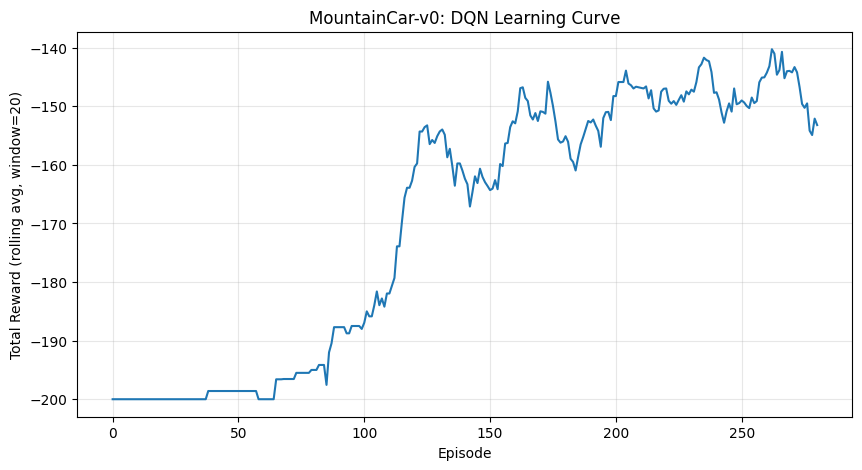

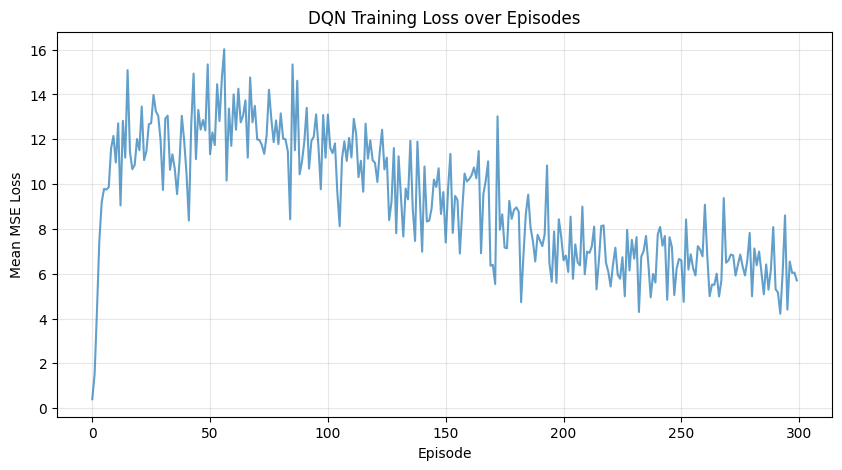

Policy              Avg Steps      Success Rate   
Random              200.0          0.0%           
DQN                 141.6          93.0%          


/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Saved hill-climb demo to mountaincar_demo.gif


In [10]:
def main():
    # Train DQN
    print("Training DQN on MountainCar-v0...")
    env = gym.make("MountainCar-v0")
    agent, episode_rewards, episode_losses = train_dqn(env, num_episodes=300)
    env.close()  # free up the environment once training is done

    # Learning curve
    # shows whether total reward improved over episodes (smoothed to reduce noise)
    plt.figure(figsize=(10, 5))
    plt.plot(rolling_average(episode_rewards))
    plt.xlabel("Episode")
    plt.ylabel("Total Reward (rolling avg, window=20)")
    plt.title("MountainCar-v0: DQN Learning Curve")
    plt.grid(alpha=0.3)
    plt.show()

    # Loss curve
    # shows whether the network's predictions were converging (loss going down) during training
    plt.figure(figsize=(10, 5))
    plt.plot(episode_losses, alpha=0.7)
    plt.xlabel("Episode")
    plt.ylabel("Mean MSE Loss")
    plt.title("DQN Training Loss over Episodes")
    plt.grid(alpha=0.3)
    plt.show()

    # Greedy-policy evaluation vs a random-policy lower bound
    # separate environment instance for evaluation, kept independent of the training env
    eval_env = gym.make("MountainCar-v0")
    avg_steps_dqn, success_dqn = evaluate_policy(eval_env, agent)
    avg_steps_random, success_random = random_policy_baseline(eval_env)
    eval_env.close()

    # print a simple side-by-side comparison table
    print(f"{'Policy':<20}{'Avg Steps':<15}{'Success Rate':<15}")
    print(f"{'Random':<20}{avg_steps_random:<15.1f}{success_random:<15.1%}")
    print(f"{'DQN':<20}{avg_steps_dqn:<15.1f}{success_dqn:<15.1%}")

    # Demo: watch the trained agent climb the hill
    # Reuses the agent that was just trained and evaluated above, so the
    # GIF matches the reported results instead of coming from a separate,
    # redundant retrain.
    record_hill_climb_gif(agent)


if __name__ == "__main__":
    # only runs main() when this file is executed directly (not when imported as a module)
    main()

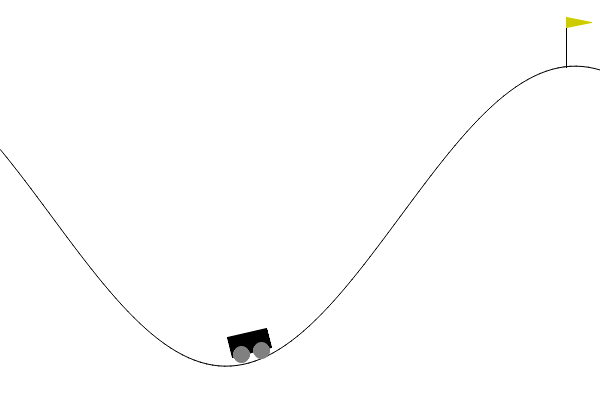

In [11]:
from IPython.display import Image
Image("mountaincar_demo.gif")